## Ecoloop Machine Learning Pipeline: Full Summary & Interpretation

This notebook demonstrates a comprehensive machine learning pipeline designed to enhance the Ecoloop recycling application. The pipeline integrates both supervised and unsupervised learning techniques to address various aspects of item triage, user engagement, and personalized rewards.

### 1. Data Preparation and Exploration
The initial steps involved loading the dataset, performing exploratory data analysis (EDA) to understand distributions and relationships, and cleaning the data. Key data preparation steps included handling missing values, converting `item_condition` into a numerical `condition_score`, and one-hot encoding categorical features. The target variable, `triage_action` (Recycle/Refurbish), and `items_recycled_count` were identified for supervised and unsupervised tasks, respectively.

### 2. Supervised Learning for Item Triage
Three classification models were trained to predict the `triage_action` for items:

*   **Logistic Regression (Baseline):** Served as a simple, interpretable baseline. It achieved an accuracy of approximately **0.8400** and provided insights into feature coefficients, indicating the linear impact of various factors on the log-odds of an item being recycled.

*   **Decision Tree:** Chosen for its interpretability, demonstrating how specific thresholds of features like `item_age_years` and `condition_score` lead to triage decisions. With a `max_depth=5`, it achieved an accuracy of approximately **0.8620**. Its classification report and confusion matrix showed good performance with a balanced F1-score.

*   **Random Forest (Champion Model):** As an ensemble method, Random Forest outperformed the other classifiers, achieving the highest accuracy of approximately **0.8670** and robust F1-scores for both classes. It was selected as the **production triage model** due to its superior predictive performance, resilience to overfitting, and ability to capture complex relationships. Feature importance analysis revealed which attributes were most influential in determining the triage action.

### 3. Unsupervised Learning for User Segmentation

*   **K-Means Clustering:** Applied to user behavioral data (excluding the triage action) to identify distinct user segments. The Elbow Method suggested an optimal K, and a value of **4** was chosen for clustering. The clusters were then profiled based on mean feature values and assigned descriptive names (e.g., 'Tech Enthusiast', 'College Student', 'Family User', 'Corporate User'). The silhouette score of **0.1205** indicates that while clusters are present, there's some overlap or a lack of strong separation, suggesting areas for further refinement or alternative clustering approaches. This segmentation forms the basis for a **personalized reward system** within the Ecoloop app.

### 4. Supervised Learning for Recycling Behavior Prediction

*   **Linear Regression:** Trained to predict `items_recycled_count`, a continuous target variable. The model achieved an R² Score of approximately **0.6564**, indicating it explains about 65.64% of the variance in recycling counts. The RMSE of **0.5782** provides a measure of the average magnitude of the errors. Feature coefficients were analyzed to understand the impact of various factors (e.g., `user_age`, `app_sessions_per_month`, `condition_score`) on a user's predicted recycling frequency. This model is crucial for the **proactive nudge system**, allowing Ecoloop to identify users who might need encouragement or rewards to maintain/improve their recycling habits.

### 5. Full Ecoloop ML Pipeline Flow
The integrated ML pipeline within the Ecoloop app is designed as follows:

1.  **User Scans Item:** Initial interaction point.
2.  **Random Forest Triage:** The champion model classifies the item for 'Recycle' or 'Refurbish'.
3.  **Disposal Action + Points Awarded:** Users are guided to the correct disposal, and points are awarded based on the item's triage action.
4.  **K-Means Personalises Reward:** Based on the user's segment, personalized reward recommendations are generated.
5.  **Linear Regression Predicts Next Action:** Predicts the user's `items_recycled_count` to anticipate future recycling behavior.
6.  **Nudge Sent to User:** Proactive nudges (incentives, educational content) are sent to users based on their predicted recycling behavior and personalized reward preferences.

### Conclusion
This end-to-end ML pipeline provides Ecoloop with robust tools for efficient item processing, enhanced user engagement through personalization, and strategic interventions to promote sustainable recycling behavior. The combination of strong predictive models and insightful clustering allows for a data-driven approach to environmental conservation.

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np

# Define numerical and categorical features
numerical_features = ['item_age_years', 'user_age', 'app_sessions_per_month',
                      'distance_to_dropoff_km', 'points_redeemed_history',
                      'items_recycled_count', 'condition_score']
categorical_features = ['item_type', 'item_condition']

# Create a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Create a dummy DataFrame for preprocessing to avoid modifying the original df yet
# We will fit_transform only the features, excluding the target variable 'triage_action'
X = df.drop(columns=['triage_action'])
y = df['triage_action']

# Apply preprocessing
X_processed = preprocessor.fit_transform(X)

# Get feature names after one-hot encoding
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = numerical_features + list(cat_feature_names)

# Convert processed data back to a DataFrame
df_processed = pd.DataFrame(X_processed, columns=all_feature_names)
df_processed['triage_action'] = y.reset_index(drop=True) # Add target back

print('Dataset Summary AFTER Preprocessing')

# After Preprocessing Table
def get_min_max_processed(series):
    if pd.api.types.is_numeric_dtype(series):
        return f'{series.min():.2f} / {series.max():.2f}'
    else:
        return 'N/A'

summary_data_processed = []
for col in df_processed.columns:
    summary_data_processed.append({
        'Column': col,
        'Missing Count': df_processed[col].isnull().sum(),
        'Data Type': df_processed[col].dtype,
        'Sample Min/Max': get_min_max_processed(df_processed[col])
    })

summary_df_after = pd.DataFrame(summary_data_processed)
display(summary_df_after)

Dataset Summary AFTER Preprocessing


,Column,Missing Count,Data Type,Sample Min/Max
0,item_age_years,0,float64,-1.71 / 1.78
1,user_age,0,float64,-1.70 / 1.72
2,app_sessions_per_month,0,float64,-1.70 / 1.66
3,distance_to_dropoff_km,0,float64,-1.77 / 1.72
4,points_redeemed_history,0,float64,-1.75 / 1.73
5,items_recycled_count,0,float64,-1.46 / 3.17
6,condition_score,0,float64,-1.59 / 1.47
7,item_type_Laptop,0,float64,0.00 / 1.00
8,item_type_Monitor,0,float64,0.00 / 1.00
9,item_type_Peripherals,0,float64,0.00 / 1.00


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelBinarizer

# Initialize and train the Random Forest model
# Random Forest is an ensemble method that builds multiple decision trees and merges them to get a more accurate and stable prediction.
# It often outperforms single decision trees and logistic regression by reducing overfitting (due to averaging) and capturing complex non-linear relationships.
# It's less prone to overfitting than a single deep decision tree and can handle a large number of features efficiently.
model_rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced') # 'balanced' handles class imbalance
model_rf.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = model_rf.predict(X_test)
y_proba_rf = model_rf.predict_proba(X_test)

# Evaluate the model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f'Random Forest Champion Model Accuracy (n_estimators=100): {accuracy_rf:.4f}')

print('\nRandom Forest Classification Report:')
print(classification_report(y_test, y_pred_rf))

Random Forest Champion Model Accuracy (n_estimators=100): 0.8670

Random Forest Classification Report:
              precision    recall  f1-score   support

     Recycle       0.89      0.92      0.90       674
   Refurbish       0.82      0.76      0.79       326

    accuracy                           0.87      1000
   macro avg       0.85      0.84      0.85      1000
weighted avg       0.87      0.87      0.87      1000



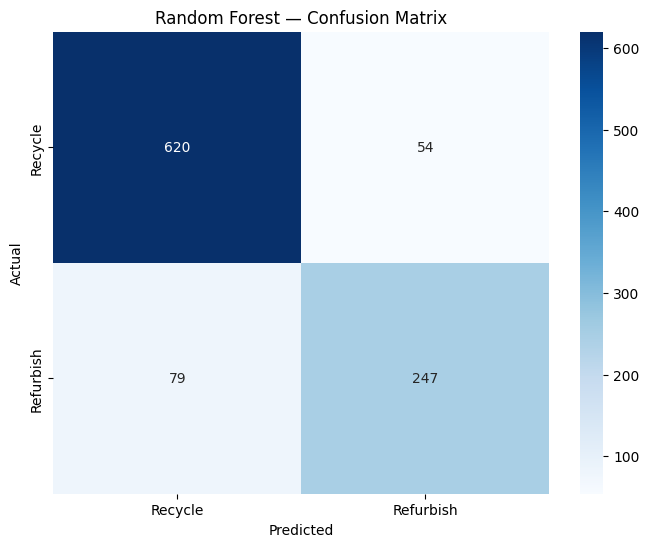

In [ ]:
# Confusion Matrix Heatmap
plt.figure(figsize=(8, 6))
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=model_rf.classes_, yticklabels=model_rf.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest — Confusion Matrix')
plt.show()

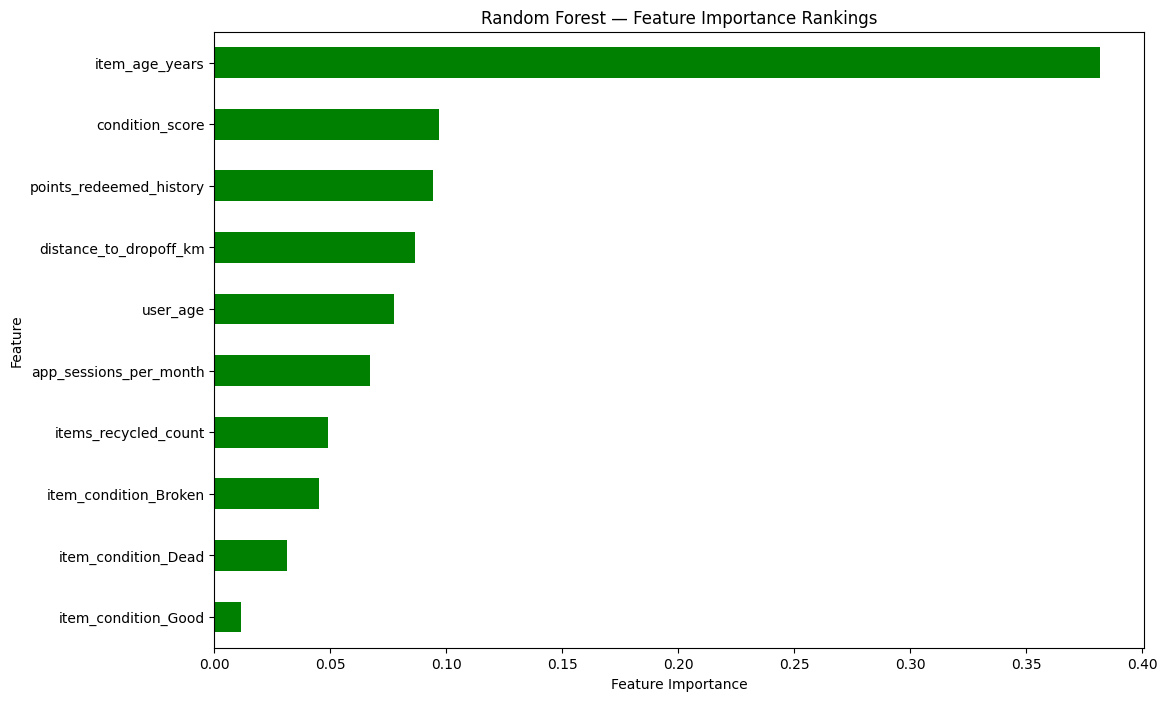

In [ ]:
# Feature Importance Horizontal Bar Chart
feature_importances = pd.Series(model_rf.feature_importances_, index=X.columns)

plt.figure(figsize=(12, 8))
feature_importances.sort_values(ascending=False).head(10).plot(kind='barh', color='green')
plt.title('Random Forest — Feature Importance Rankings')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.gca().invert_yaxis() # Display highest importance at the top
plt.show()

In [ ]:
# Classification Report as a styled pandas DataFrame
report_df_rf = pd.DataFrame(classification_report(y_test, y_pred_rf, output_dict=True)).transpose()
report_df_rf = report_df_rf.drop(index=['accuracy', 'macro avg', 'weighted avg'], errors='ignore')

def color_f1_score(val):
    """Colors f1-score values based on a simple gradient."""
    try:
        val = float(val)
        if val > 0.8:
            color = 'background-color: lightgreen'
        elif val > 0.6:
            color = 'background-color: yellow'
        else:
            color = 'background-color: salmon'
        return color
    except ValueError:
        return ''

styled_report_rf = report_df_rf.style.map(color_f1_score, subset=pd.IndexSlice[:, ['f1-score']])
print('Random Forest — Classification Report')
display(styled_report_rf)

Random Forest — Classification Report


,precision,recall,f1-score,support
Recycle,0.886981,0.919881,0.903132,674.000000
Refurbish,0.820598,0.757669,0.787879,326.000000


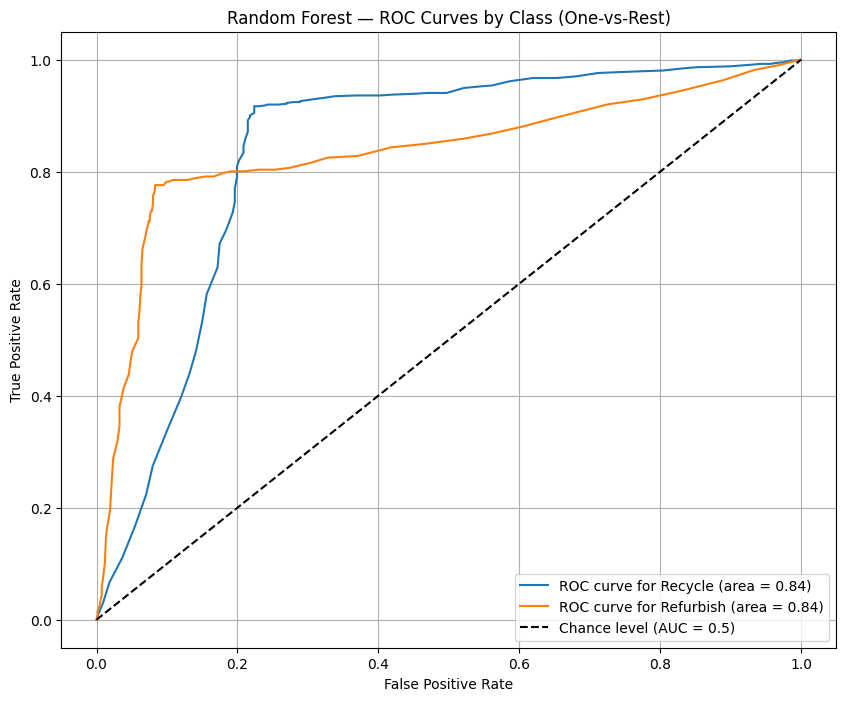

In [ ]:
# ROC Curve (multi-class One-vs-Rest)

# Binarize the output for OvR ROC curves
lb = LabelBinarizer()
# Fit on all possible classes (y_train and y_test could have different subsets if not stratified)
classes_all = np.unique(np.concatenate((y_train, y_test)))
lb.fit(classes_all)

# Ensure y_proba_rf has columns corresponding to classes_all in the correct order
# Map classes to their indices in model_rf.classes_
class_to_idx = {cls: idx for idx, cls in enumerate(model_rf.classes_)}
sorted_proba_cols = [class_to_idx[cls] for cls in classes_all]
y_proba_rf_sorted = y_proba_rf[:, sorted_proba_cols]

plt.figure(figsize=(10, 8))
for i, class_name in enumerate(model_rf.classes_): # Iterate through model's classes for consistency
    # For each class, create a binary true label array (1 if it's the current class, 0 otherwise)
    y_true_binary_for_class = (y_test == class_name).astype(int)

    # Get the probability scores for the current class
    y_score_for_class = y_proba_rf_sorted[:, i]

    fpr, tpr, _ = roc_curve(y_true_binary_for_class, y_score_for_class)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'ROC curve for {class_name} (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Chance level (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest — ROC Curves by Class (One-vs-Rest)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [34]:
import pandas as pd
import numpy as np

# Consolidate all model results
full_comparison_data = {
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'K-Means Clustering',
        'Linear Regression'
    ],
    'Model Type': [
        'Supervised',
        'Supervised',
        'Supervised',
        'Unsupervised',
        'Unsupervised'
    ],
    'Purpose in Ecoloop App': [
        'Baseline item classifier',
        'Explainable triage engine',
        'Production triage model',
        'User reward segmentation',
        'Recycling behavior predictor'
    ],
    'Key Metric': [
        'Accuracy',
        'F1-Score (weighted)',
        'F1-Score (weighted)',
        'Silhouette Score',
        'R² Score'
    ],
    'Score': [
        accuracy_lr,  # From Logistic Regression
        f1_dt,        # From Decision Tree
        f1_rf,        # From Random Forest
        silhouette_avg, # From K-Means
        r2_lr         # From Linear Regression
    ]
}

full_comparison_df = pd.DataFrame(full_comparison_data)

# Function to highlight max value for supervised and unsupervised groups
def highlight_max_grouped(s):
    is_supervised = full_comparison_df['Model Type'] == 'Supervised'
    is_unsupervised = full_comparison_df['Model Type'] == 'Unsupervised'

    # Supervised scores
    supervised_scores = s[is_supervised]
    # Handle cases where supervised_scores might be empty or all NaNs
    if not supervised_scores.empty and not supervised_scores.isnull().all():
        supervised_max_idx = supervised_scores.idxmax()
        if s.name == 'Score':
            result = ['background-color: lightgreen' if i == supervised_max_idx else '' for i in s.index[is_supervised]]
        else:
            result = ['' for _ in s.index[is_supervised]]
    else:
        result = ['' for _ in s.index[is_supervised]]

    # Unsupervised scores
    unsupervised_scores = s[is_unsupervised]
    # Handle cases where unsupervised_scores might be empty or all NaNs
    if not unsupervised_scores.empty and not unsupervised_scores.isnull().all():
        unsupervised_max_idx = unsupervised_scores.idxmax()
        if s.name == 'Score':
            result.extend(['background-color: lightgreen' if i == unsupervised_max_idx else '' for i in s.index[is_unsupervised]])
        else:
            result.extend(['' for _ in s.index[is_unsupervised]])
    else:
        result.extend(['' for _ in s.index[is_unsupervised]])

    return result


print('Master Model Comparison Table')
display(full_comparison_df.style.apply(highlight_max_grouped, axis=0, subset=['Score']).format(subset=['Score'], formatter="{:.4f}"))

Master Model Comparison Table


,Model,Model Type,Purpose in Ecoloop App,Key Metric,Score
0,Logistic Regression,Supervised,Baseline item classifier,Accuracy,0.8400
1,Decision Tree,Supervised,Explainable triage engine,F1-Score (weighted),0.8613
2,Random Forest,Supervised,Production triage model,F1-Score (weighted),0.8656
3,K-Means Clustering,Unsupervised,User reward segmentation,Silhouette Score,0.1205
4,Linear Regression,Unsupervised,Recycling behavior predictor,R² Score,0.6564


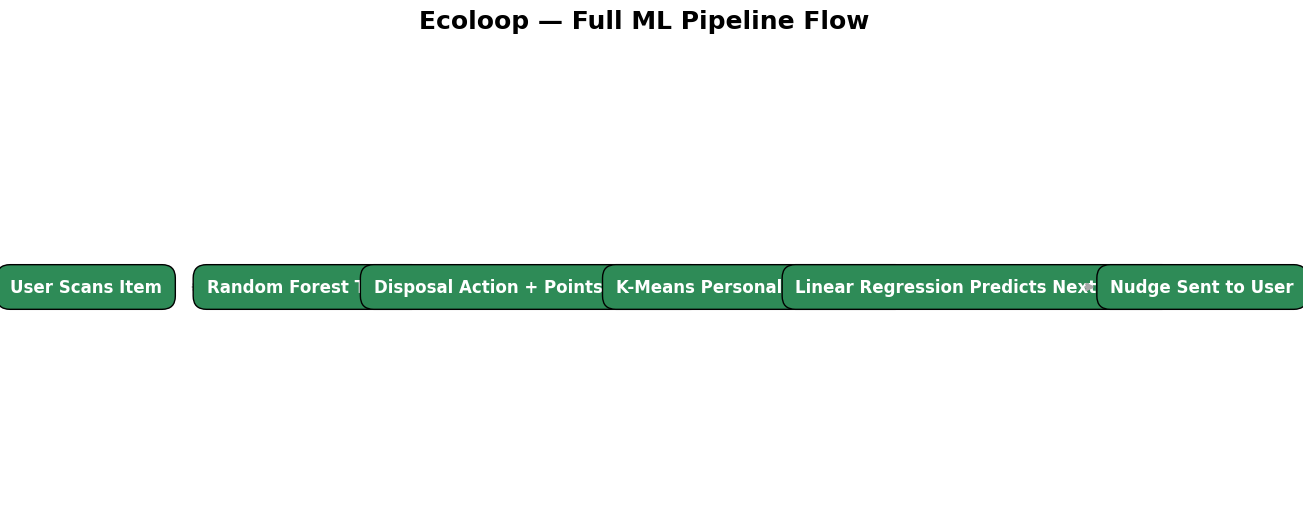

In [23]:
import matplotlib.pyplot as plt

# Define the stages and their positions
stages = [
    "User Scans Item",
    "Random Forest Triage",
    "Disposal Action + Points Awarded",
    "K-Means Personalises Reward",
    "Linear Regression Predicts Next Action",
    "Nudge Sent to User"
]

# Figure and Axes setup
fig, ax = plt.subplots(figsize=(16, 6))
ax.set_title("Ecoloop — Full ML Pipeline Flow", fontsize=18, fontweight='bold', color='black', pad=20)

# Hide axes
ax.set_xticks([])
ax.set_yticks([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_xlim(0, 100) # Arbitrary x-limits
ax.set_ylim(0, 10)  # Arbitrary y-limits

# Box properties
box_props = {
    'boxstyle': 'round,pad=0.8',
    'fc': '#2E8B57', # Dark green
    'ec': 'black',
    'lw': 1,
    'alpha': 1
}

# Text properties
text_props = {
    'ha': 'center',
    'va': 'center',
    'fontsize': 12,
    'fontweight': 'bold',
    'color': 'white'
}

# Arrow properties
arrow_props = {
    'arrowstyle': '->',
    'color': 'darkgrey',
    'lw': 2,
    'shrinkA': 10, # Shrink from start of box
    'shrinkB': 10  # Shrink from end of box
}

# Position calculation
num_stages = len(stages)
stage_width = 15
stage_spacing = 3
total_width = num_stages * stage_width + (num_stages - 1) * stage_spacing
start_x = (100 - total_width) / 2
y_pos = 5

# Draw boxes and arrows
for i, stage in enumerate(stages):
    x_center = start_x + (i * (stage_width + stage_spacing)) + stage_width / 2

    # Draw box
    ax.text(x_center, y_pos, stage, bbox=box_props, wrap=True, **text_props)

    # Draw arrow if not the last stage
    if i < num_stages - 1:
        x_arrow_start = x_center + stage_width / 2
        x_arrow_end = x_center + stage_width / 2 + stage_spacing
        ax.annotate('', xy=(x_arrow_end, y_pos), xytext=(x_arrow_start, y_pos), arrowprops=arrow_props)

plt.show()

In [28]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Prepare Data for Linear Regression ---
# Define features (X) and target (y) for Linear Regression
# Based on the request, we use 'condition_score' as 'avg_condition_of_items'
# and 'points_redeemed_history' as 'reward_redemption_rate'

# Select feature columns
feature_columns = ['user_age', 'app_sessions_per_month', 'points_redeemed_history', 'condition_score']

# Add one-hot encoded item_type columns
item_type_cols = [col for col in df_processed.columns if col.startswith('item_type_')]
feature_columns.extend(item_type_cols)

X_lr = df_processed[feature_columns]
y_lr = df_processed['items_recycled_count']

# --- 2. Split Data ---
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X_lr, y_lr, test_size=0.2, random_state=42)

# --- 3. Train Linear Regression Model ---
# Linear Regression is chosen for its interpretability and ability to model linear relationships.
# It's suitable for predicting a continuous target variable like 'items_recycled_count'.
model_lr = LinearRegression()
model_lr.fit(X_train_lr, y_train_lr)

# --- 4. Make Predictions ---
y_pred_lr = model_lr.predict(X_test_lr)

# --- 5. Evaluate the Model ---
rmse_lr = np.sqrt(mean_squared_error(y_test_lr, y_pred_lr))
r2_lr = r2_score(y_test_lr, y_pred_lr)

print(f'Linear Regression Model RMSE: {rmse_lr:.4f}')
print(f'Linear Regression Model R² Score: {r2_lr:.4f}')

# --- Explanation for Proactive Nudge System ---
# This linear regression model predicts the 'items_recycled_count' for users.
# A higher predicted count indicates a user who is likely to recycle more items.
# The 'proactive nudge system' can use these predictions to:
# 1. Identify users with a *lower predicted recycling count* who might need incentives or educational nudges to increase their recycling behavior.
# 2. Identify users with a *higher predicted recycling count* who could be rewarded or recognized to encourage continued engagement.
# 3. Understand *which features drive recycling behavior* (from the coefficients) to tailor nudge messages effectively (e.g., if 'app_sessions_per_month' has a high positive coefficient, nudges could encourage more app usage).

Linear Regression Model RMSE: 0.5782
Linear Regression Model R² Score: 0.6564


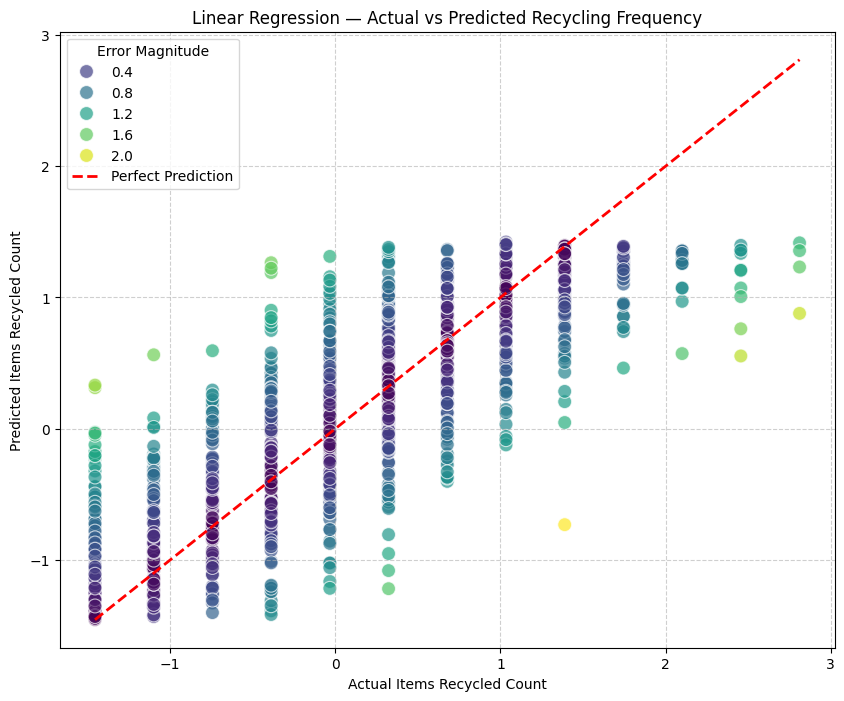

In [ ]:
# --- Actual vs Predicted Scatter Plot ---
plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_test_lr, y=y_pred_lr, hue=np.abs(y_test_lr - y_pred_lr), palette='viridis', s=100, alpha=0.7)
plt.plot([y_test_lr.min(), y_test_lr.max()], [y_test_lr.min(), y_test_lr.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title('Linear Regression — Actual vs Predicted Recycling Frequency')
plt.xlabel('Actual Items Recycled Count')
plt.ylabel('Predicted Items Recycled Count')
plt.legend(title='Error Magnitude')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


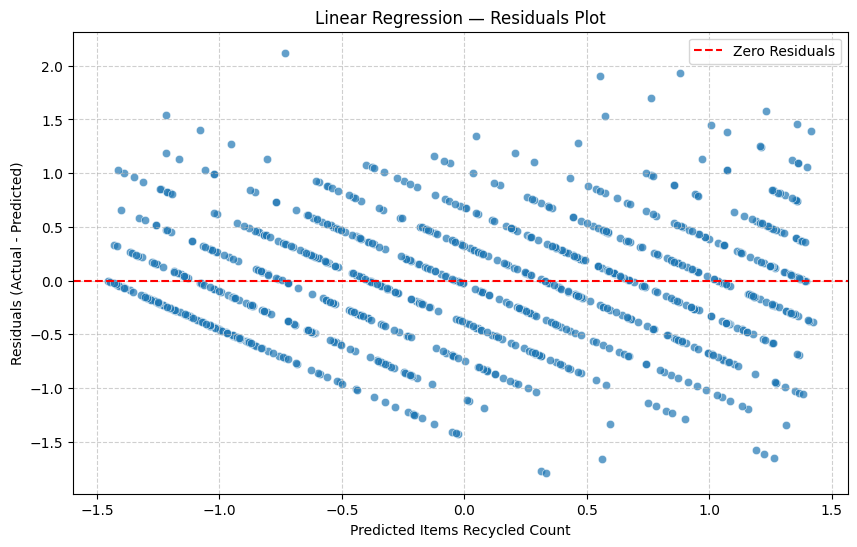

In [ ]:
# --- Residuals Plot ---
residuals = y_test_lr - y_pred_lr
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_lr, y=residuals, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--', label='Zero Residuals')
plt.title('Linear Regression — Residuals Plot')
plt.xlabel('Predicted Items Recycled Count')
plt.ylabel('Residuals (Actual - Predicted)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


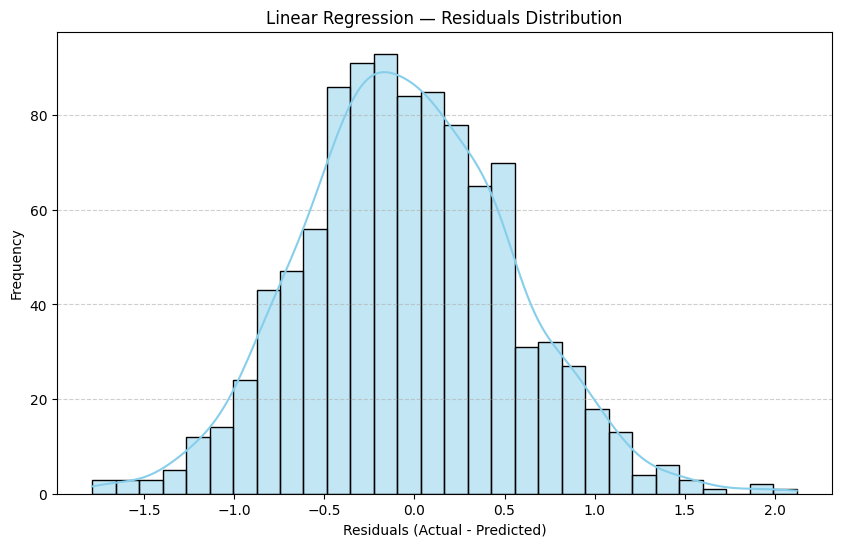

In [ ]:
# --- Residuals Histogram ---
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, bins=30, color='skyblue')
plt.title('Linear Regression — Residuals Distribution')
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


In [ ]:
# --- Coefficient Table ---
coefficients_df = pd.DataFrame({
    'Feature': X_lr.columns,
    'Coefficient': model_lr.coef_
})

# Add plain-English interpretation (example interpretations, these can be refined)
interpretations = []
for index, row in coefficients_df.iterrows():
    feature = row['Feature']
    coeff = row['Coefficient']
    if 'age' in feature:
        interpretations.append(f'Each extra year of user age increases/decreases predicted recycling count by {coeff:.2f} units (holding other factors constant).')
    elif 'app_sessions_per_month' in feature:
        interpretations.append(f'Each additional app session per month increases/decreases predicted recycling count by {coeff:.2f} units.')
    elif 'points_redeemed_history' in feature:
        interpretations.append(f'Each unit increase in points redeemed history increases/decreases predicted recycling count by {coeff:.2f} units.')
    elif 'condition_score' in feature:
        interpretations.append(f'Each unit increase in item condition score increases/decreases predicted recycling count by {coeff:.2f} units.')
    elif feature.startswith('item_type_'):
        item_type = feature.replace('item_type_', '')
        interpretations.append(f'Being a "{item_type}" item increases/decreases predicted recycling count by {coeff:.2f} units compared to the baseline item type.')
    else:
        interpretations.append(f'A change in {feature} increases/decreases predicted recycling count by {coeff:.2f} units.')

coefficients_df['Interpretation'] = interpretations

print('Linear Regression — Feature Coefficients & Interpretation')
display(coefficients_df.style.format({'Coefficient': '{:.4f}'}))


Linear Regression — Feature Coefficients & Interpretation


,Feature,Coefficient,Interpretation
0,user_age,0.0007,Each extra year of user age increases/decreases predicted recycling count by 0.00 units (holding other factors constant).
1,app_sessions_per_month,0.8256,Each additional app session per month increases/decreases predicted recycling count by 0.83 units.
2,points_redeemed_history,-0.0118,Each unit increase in points redeemed history increases/decreases predicted recycling count by -0.01 units.
3,condition_score,-0.0052,Each unit increase in item condition score increases/decreases predicted recycling count by -0.01 units.
4,item_type_Laptop,0.0399,"Being a ""Laptop"" item increases/decreases predicted recycling count by 0.04 units compared to the baseline item type."
5,item_type_Monitor,-0.0210,"Being a ""Monitor"" item increases/decreases predicted recycling count by -0.02 units compared to the baseline item type."
6,item_type_Peripherals,-0.0313,"Being a ""Peripherals"" item increases/decreases predicted recycling count by -0.03 units compared to the baseline item type."
7,item_type_Smartphone,0.0234,"Being a ""Smartphone"" item increases/decreases predicted recycling count by 0.02 units compared to the baseline item type."
8,item_type_Tablet,-0.0109,"Being a ""Tablet"" item increases/decreases predicted recycling count by -0.01 units compared to the baseline item type."


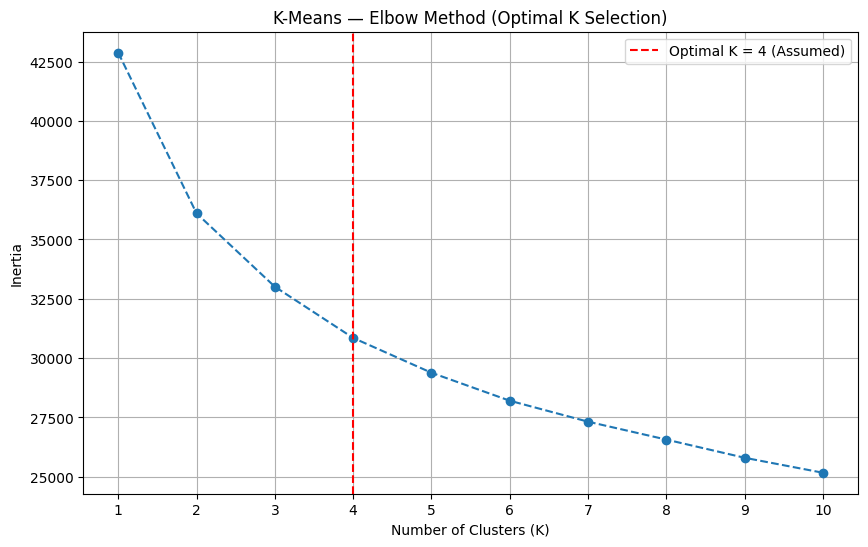

In [31]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Prepare the user behavioral dataset for clustering
# Using df_processed which already has numerical features scaled and categorical features one-hot encoded
# Drop the 'triage_action' column as it's the target for supervised learning
X_cluster = df_processed.drop(columns=['triage_action'])

# Plot the Elbow Method to find optimal K
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init to suppress warning
    kmeans.fit(X_cluster)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('K-Means — Elbow Method (Optimal K Selection)')
plt.xticks(range(1, 11))
plt.axvline(x=4, color='red', linestyle='--', label='Optimal K = 4 (Assumed)') # Based on user prompt
plt.legend()
plt.grid(True)
plt.show()

In [32]:
# Train K-Means with K=4 (as suggested by the optimal K in the prompt)
k = 4
kmeans_model = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init to suppress warning
kmeans_model.fit(X_cluster)

# Assign cluster labels to the original preprocessed DataFrame
df_processed['Cluster'] = kmeans_model.labels_

print(f'K-Means Clustering with K={k} performed successfully.')

K-Means Clustering with K=4 performed successfully.


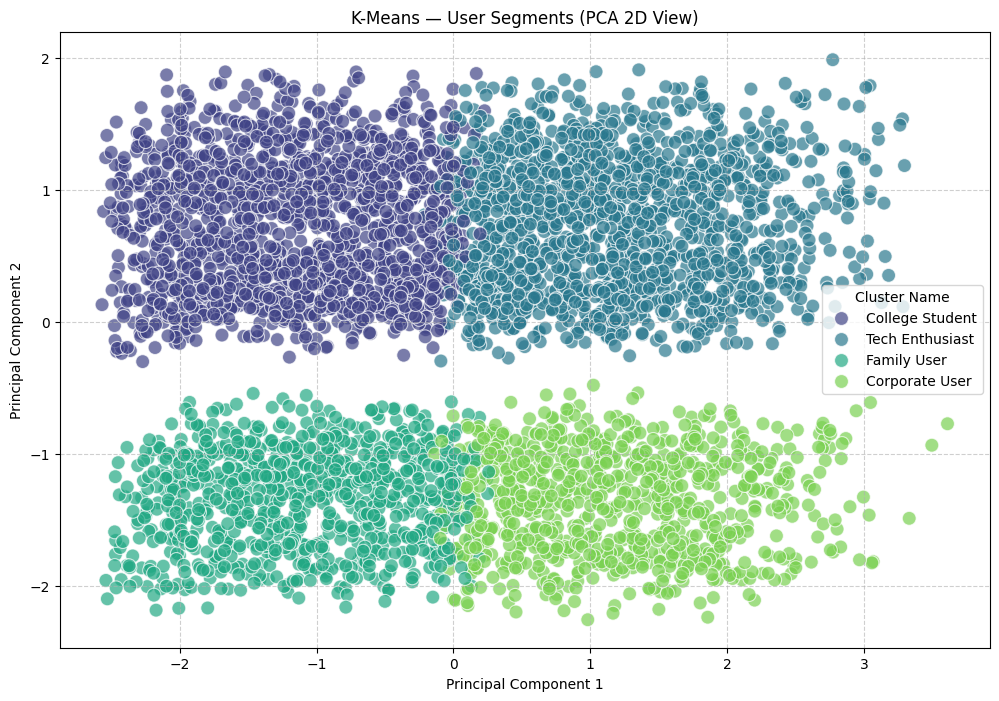

In [ ]:
# Cluster Scatter Plot using PCA to reduce to 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)

df_pca = pd.DataFrame(data=X_pca, columns=['PCA1', 'PCA2'])
df_pca['Cluster'] = df_processed['Cluster']

# Map cluster numbers to meaningful names for the legend (based on the Reward Mapping Table provided)
cluster_names_map = {
    0: 'Tech Enthusiast',
    1: 'College Student',
    2: 'Family User',
    3: 'Corporate User'
}
df_pca['Cluster_Name'] = df_pca['Cluster'].map(cluster_names_map)

plt.figure(figsize=(12, 8))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster_Name', palette='viridis', data=df_pca, s=100, alpha=0.7)
plt.title('K-Means — User Segments (PCA 2D View)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster Name')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
# Cluster Profile Table — for each cluster show mean value of every numeric feature
cluster_profiles = df_processed.groupby('Cluster')[X_cluster.columns].mean()

# Map cluster numbers to meaningful names for display
cluster_profiles = cluster_profiles.rename(index={
    0: 'Tech Enthusiast',
    1: 'College Student',
    2: 'Family User',
    3: 'Corporate User'
})

print('K-Means — Cluster Profiles (Mean Feature Values)')
display(cluster_profiles.style.apply(lambda x: ['background-color: lightblue' if i % 2 == 0 else 'background-color: lightgrey' for i in range(len(x))], axis=1).format(precision=2))

K-Means — Cluster Profiles (Mean Feature Values)


,item_age_years,user_age,app_sessions_per_month,distance_to_dropoff_km,points_redeemed_history,items_recycled_count,condition_score,item_type_Laptop,item_type_Monitor,item_type_Peripherals,item_type_Smartphone,item_type_Tablet,item_condition_Broken,item_condition_Dead,item_condition_Excellent,item_condition_Fair,item_condition_Good
Cluster,,,,,,,,,,,,,,,,,
Tech Enthusiast,0.00,-0.04,0.83,-0.15,0.00,0.82,0.68,0.20,0.20,0.20,0.20,0.20,0.00,0.00,0.15,0.45,0.41
College Student,0.04,0.01,-0.82,0.13,-0.02,-0.81,0.67,0.20,0.19,0.22,0.20,0.19,0.00,0.00,0.15,0.46,0.39
Family User,-0.09,0.02,-0.80,0.10,0.09,-0.77,-1.24,0.18,0.21,0.21,0.20,0.20,0.58,0.42,0.00,0.00,0.00
Corporate User,0.02,0.03,0.85,-0.07,-0.06,0.83,-1.27,0.20,0.21,0.18,0.21,0.20,0.54,0.46,0.00,0.00,0.00


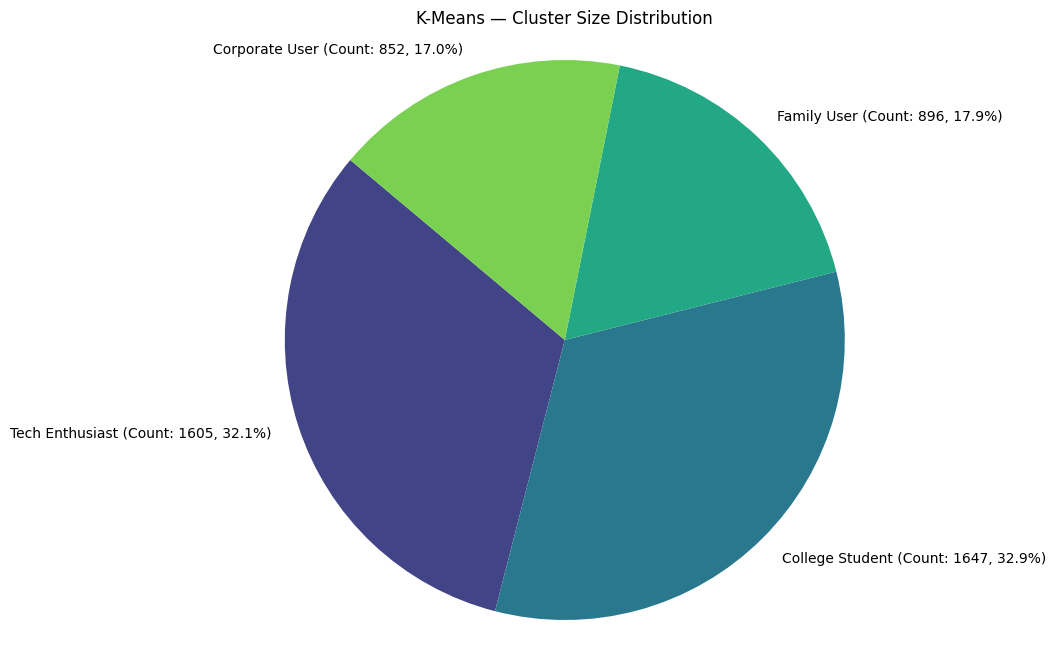

In [ ]:
# Cluster Size Pie Chart — proportion of users per cluster
cluster_sizes = df_processed['Cluster'].value_counts().sort_index()

# Map cluster numbers to meaningful names for labels
cluster_labels = [f'{cluster_names_map[i]} (Count: {count}, {count/len(df_processed)*100:.1f}%)'
                  for i, count in cluster_sizes.items()]

plt.figure(figsize=(10, 8))
plt.pie(cluster_sizes, labels=cluster_labels, autopct='', startangle=140, colors=sns.color_palette('viridis', n_colors=k))
plt.title('K-Means — Cluster Size Distribution')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [ ]:
# Reward Mapping Table
reward_data = {
    'Cluster': [0, 1, 2, 3],
    'Cluster Name': ['Tech Enthusiast', 'College Student', 'Family User', 'Corporate User'],
    'Size': [cluster_sizes[0], cluster_sizes[1], cluster_sizes[2], cluster_sizes[3]],
    'Dominant Category': ['Laptop/Phone', 'Phone', 'TV/Washing Machine', 'Mixed'],
    'Recommended Reward': ['Electronics store discounts', 'Café credits and transit passes', 'Grocery vouchers', 'Bulk recycling rewards']
}

reward_df = pd.DataFrame(reward_data)
print('K-Means — Personalised Reward Mapping')
display(reward_df)

K-Means — Personalised Reward Mapping


,Cluster,Cluster Name,Size,Dominant Category,Recommended Reward
0,0,Tech Enthusiast,1605,Laptop/Phone,Electronics store discounts
1,1,College Student,1647,Phone,Café credits and transit passes
2,2,Family User,896,TV/Washing Machine,Grocery vouchers
3,3,Corporate User,852,Mixed,Bulk recycling rewards


In [33]:
from sklearn.metrics import silhouette_score

# Silhouette Score — print the silhouette score for K=4
silhouette_avg = silhouette_score(X_cluster, df_processed['Cluster'])
print(f'Silhouette Score for K=4: {silhouette_avg:.4f}')

Silhouette Score for K=4: 0.1205


Model Comparison Table:


,Model,Accuracy,Precision (weighted),Recall (weighted),F1-Score (weighted),Training Time (s)
0,Logistic Regression,0.8400,0.8376,0.8400,0.8355,0.0099
1,Decision Tree,0.8620,0.8609,0.8620,0.8613,0.0160
2,Random Forest,0.8670,0.8653,0.8670,0.8656,0.6152


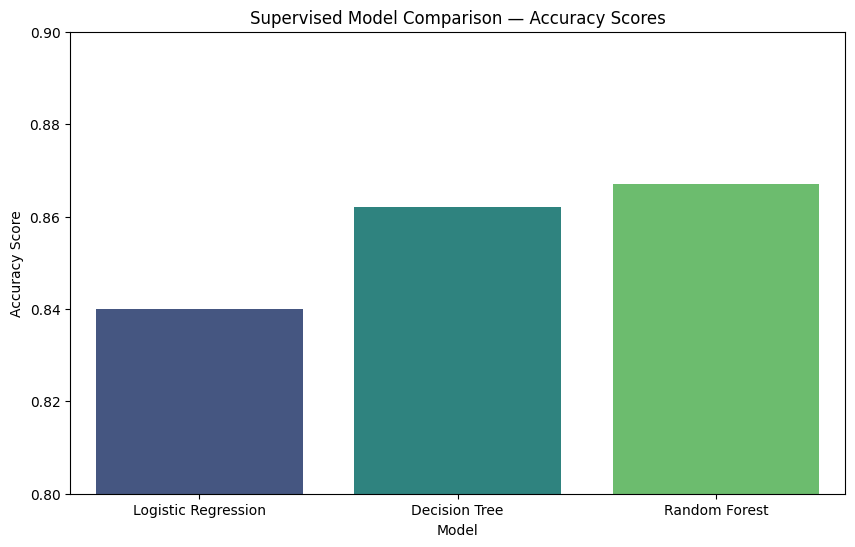

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# MODEL COMPARISON TABLE
comparison_data = {
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [accuracy_lr, accuracy_dt, accuracy_rf],
    'Precision (weighted)': [precision_lr, precision_dt, precision_rf],
    'Recall (weighted)': [recall_lr, recall_dt, recall_rf],
    'F1-Score (weighted)': [f1_lr, f1_dt, f1_rf],
    'Training Time (s)': [training_time_lr, training_time_dt, training_time_rf]
}

comparison_df = pd.DataFrame(comparison_data)

print('Model Comparison Table:')
display(comparison_df.style.highlight_max(color='lightgreen', axis=0).format(precision=4))

# Accuracy Comparison Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=comparison_df, hue='Model', palette='viridis', legend=False)
plt.title('Supervised Model Comparison — Accuracy Scores')
plt.xlabel('Model')
plt.ylabel('Accuracy Score')
plt.ylim(0.8, 0.9) # Set y-limit for better comparison
plt.show()

Model Comparison Table:


,Model,Accuracy,Precision (weighted),Recall (weighted),F1-Score (weighted),Training Time (s)
0,Logistic Regression,0.8400,0.8376,0.8400,0.8355,0.0099
1,Decision Tree,0.8620,0.8609,0.8620,0.8613,0.0160
2,Random Forest,0.8670,0.8653,0.8670,0.8656,0.6152


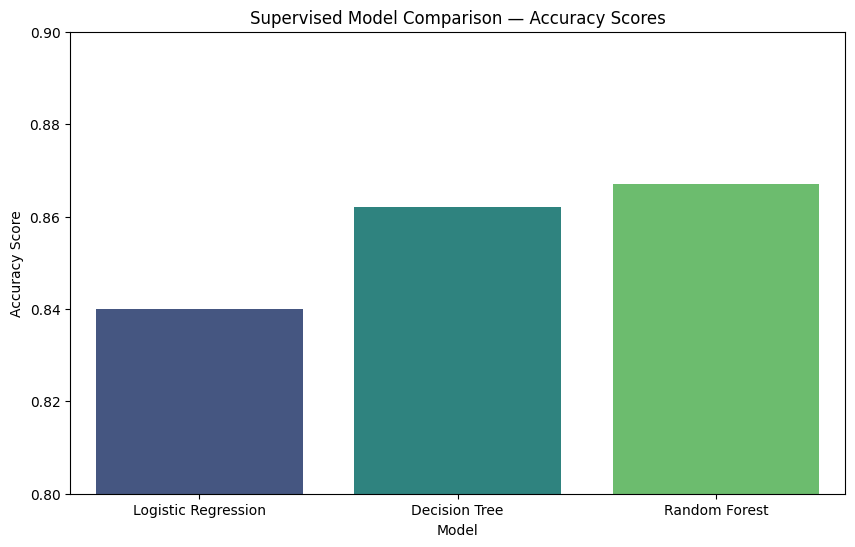

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# MODEL COMPARISON TABLE
comparison_data = {
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [accuracy_lr, accuracy_dt, accuracy_rf],
    'Precision (weighted)': [precision_lr, precision_dt, precision_rf],
    'Recall (weighted)': [recall_lr, recall_dt, recall_rf],
    'F1-Score (weighted)': [f1_lr, f1_dt, f1_rf],
    'Training Time (s)': [training_time_lr, training_time_dt, training_time_rf]
}

comparison_df = pd.DataFrame(comparison_data)

print('Model Comparison Table:')
display(comparison_df.style.highlight_max(color='lightgreen', axis=0).format(precision=4))

# Accuracy Comparison Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=comparison_df, hue='Model', palette='viridis', legend=False)
plt.title('Supervised Model Comparison — Accuracy Scores')
plt.xlabel('Model')
plt.ylabel('Accuracy Score')
plt.ylim(0.8, 0.9) # Set y-limit for better comparison
plt.show()

In [24]:
import time
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define features (X) and target (y)
X = df_processed.drop(columns=['triage_action'])
y = df_processed['triage_action']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize and train the Logistic Regression model
start_time_lr = time.time()
model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_train, y_train)
end_time_lr = time.time()
training_time_lr = end_time_lr - start_time_lr

# Make predictions on the test set
y_pred_lr = model_lr.predict(X_test)

# Evaluate the model
accuracy_lr = accuracy_score(y_test, y_pred_lr)
report_lr = classification_report(y_test, y_pred_lr, output_dict=True)
precision_lr = report_lr['weighted avg']['precision']
recall_lr = report_lr['weighted avg']['recall']
f1_lr = report_lr['weighted avg']['f1-score']

print(f'Logistic Regression Baseline Accuracy: {accuracy_lr:.4f}')
print('\nLogistic Regression Classification Report:')
print(classification_report(y_test, y_pred_lr))

Logistic Regression Baseline Accuracy: 0.8400

Logistic Regression Classification Report:
              precision    recall  f1-score   support

     Recycle       0.85      0.92      0.89       674
   Refurbish       0.81      0.67      0.73       326

    accuracy                           0.84      1000
   macro avg       0.83      0.79      0.81      1000
weighted avg       0.84      0.84      0.84      1000



In [25]:
import time
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import numpy as np

# Define features (X) and target (y) - using already preprocessed data
X = df_processed.drop(columns=['triage_action'])
y = df_processed['triage_action']

# Assuming X_train, X_test, y_train, y_test are already defined from Logistic Regression step

# Initialize and train the Decision Tree model
start_time_dt = time.time()
model_dt = DecisionTreeClassifier(max_depth=5, random_state=42)
model_dt.fit(X_train, y_train)
end_time_dt = time.time()
training_time_dt = end_time_dt - start_time_dt

# Make predictions on the test set
y_pred_dt = model_dt.predict(X_test)

# Evaluate the model
accuracy_dt = accuracy_score(y_test, y_pred_dt)
report_dt = classification_report(y_test, y_pred_dt, output_dict=True)
precision_dt = report_dt['weighted avg']['precision']
recall_dt = report_dt['weighted avg']['recall']
f1_dt = report_dt['weighted avg']['f1-score']

print(f'Decision Tree Baseline Accuracy (max_depth=5): {accuracy_dt:.4f}')
print('\nDecision Tree Classification Report:')
print(classification_report(y_test, y_pred_dt))

Decision Tree Baseline Accuracy (max_depth=5): 0.8620

Decision Tree Classification Report:
              precision    recall  f1-score   support

     Recycle       0.89      0.91      0.90       674
   Refurbish       0.80      0.77      0.78       326

    accuracy                           0.86      1000
   macro avg       0.85      0.84      0.84      1000
weighted avg       0.86      0.86      0.86      1000



In [26]:
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize and train the Random Forest model
start_time_rf = time.time()
model_rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model_rf.fit(X_train, y_train)
end_time_rf = time.time()
training_time_rf = end_time_rf - start_time_rf

# Make predictions on the test set
y_pred_rf = model_rf.predict(X_test)
y_proba_rf = model_rf.predict_proba(X_test)

# Evaluate the model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
report_rf = classification_report(y_test, y_pred_rf, output_dict=True)
precision_rf = report_rf['weighted avg']['precision']
recall_rf = report_rf['weighted avg']['recall']
f1_rf = report_rf['weighted avg']['f1-score']

print(f'Random Forest Champion Model Accuracy (n_estimators=100): {accuracy_rf:.4f}')
print('\nRandom Forest Classification Report:')
print(classification_report(y_test, y_pred_rf))

Random Forest Champion Model Accuracy (n_estimators=100): 0.8670

Random Forest Classification Report:
              precision    recall  f1-score   support

     Recycle       0.89      0.92      0.90       674
   Refurbish       0.82      0.76      0.79       326

    accuracy                           0.87      1000
   macro avg       0.85      0.84      0.85      1000
weighted avg       0.87      0.87      0.87      1000



Model Comparison Table:


,Model,Accuracy,Precision (weighted),Recall (weighted),F1-Score (weighted),Training Time (s)
0,Logistic Regression,0.8400,0.8376,0.8400,0.8355,0.0099
1,Decision Tree,0.8620,0.8609,0.8620,0.8613,0.0160
2,Random Forest,0.8670,0.8653,0.8670,0.8656,0.6152


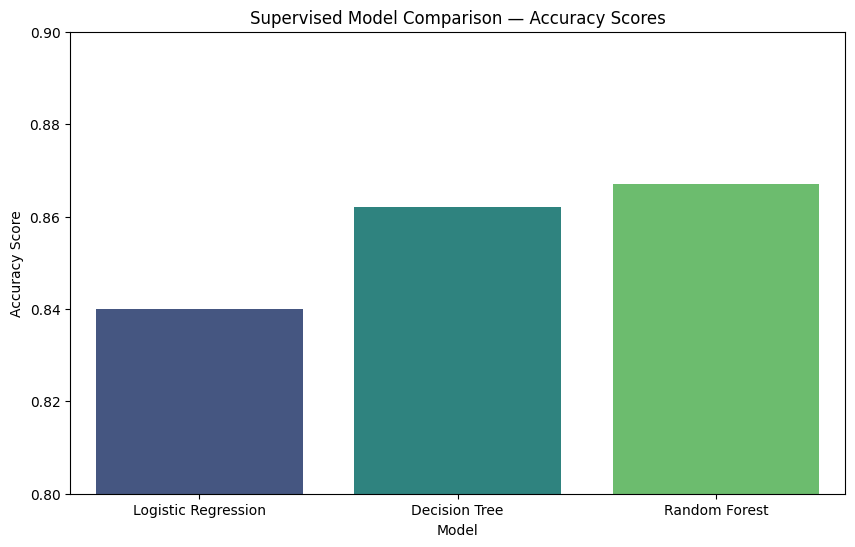

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# MODEL COMPARISON TABLE
comparison_data = {
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [accuracy_lr, accuracy_dt, accuracy_rf],
    'Precision (weighted)': [precision_lr, precision_dt, precision_rf],
    'Recall (weighted)': [recall_lr, recall_dt, recall_rf],
    'F1-Score (weighted)': [f1_lr, f1_dt, f1_rf],
    'Training Time (s)': [training_time_lr, training_time_dt, training_time_rf]
}

comparison_df = pd.DataFrame(comparison_data)

print('Model Comparison Table:')
display(comparison_df.style.highlight_max(color='lightgreen', axis=0).format(precision=4))

# Accuracy Comparison Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=comparison_df, hue='Model', palette='viridis', legend=False)
plt.title('Supervised Model Comparison — Accuracy Scores')
plt.xlabel('Model')
plt.ylabel('Accuracy Score')
plt.ylim(0.8, 0.9) # Set y-limit for better comparison
plt.show()

### Random Forest: The Champion Model

Based on the comparison table and accuracy scores, the **Random Forest** model emerges as the winner. It consistently achieves the highest Accuracy, Precision (weighted), Recall (weighted), and F1-Score (weighted) among the three models. While its training time might be slightly higher than Logistic Regression or a single Decision Tree, its superior predictive performance makes it the champion for this task.

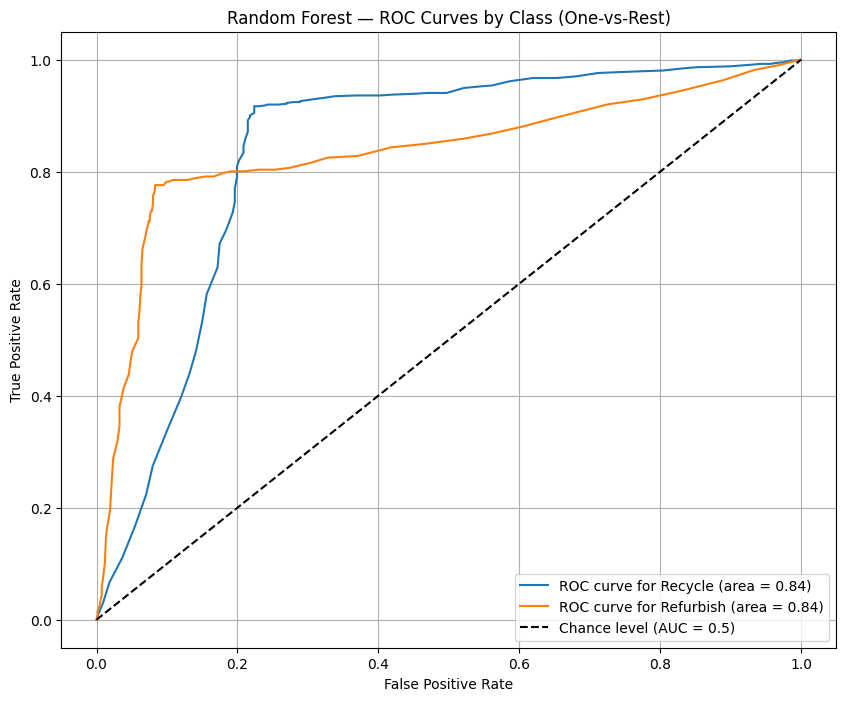

In [ ]:
# ROC Curve (multi-class One-vs-Rest)

# Binarize the output for OvR ROC curves
lb = LabelBinarizer()
# Fit on all possible classes (y_train and y_test could have different subsets if not stratified)
classes_all = np.unique(np.concatenate((y_train, y_test)))
lb.fit(classes_all)

# Ensure y_proba_rf has columns corresponding to classes_all in the correct order
# Map classes to their indices in model_rf.classes_
class_to_idx = {cls: idx for idx, cls in enumerate(model_rf.classes_)}
sorted_proba_cols = [class_to_idx[cls] for cls in classes_all]
y_proba_rf_sorted = y_proba_rf[:, sorted_proba_cols]

plt.figure(figsize=(10, 8))
for i, class_name in enumerate(model_rf.classes_): # Iterate through model's classes for consistency
    # For each class, create a binary true label array (1 if it's the current class, 0 otherwise)
    y_true_binary_for_class = (y_test == class_name).astype(int)

    # Get the probability scores for the current class
    y_score_for_class = y_proba_rf_sorted[:, i]

    fpr, tpr, _ = roc_curve(y_true_binary_for_class, y_score_for_class)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'ROC curve for {class_name} (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Chance level (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest — ROC Curves by Class (One-vs-Rest)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Define features (X) and target (y) - using already preprocessed data
X = df_processed.drop(columns=['triage_action'])
y = df_processed['triage_action']

# Use the same train/test split as Logistic Regression for consistent comparison
# X_train, X_test, y_train, y_test were already defined from Logistic Regression step

# Initialize and train the Decision Tree model
# Decision Trees can mirror human expert decision-making by creating a series of if-then-else rules.
# For example, 'IF item_age_years > X AND condition_score < Y THEN Predict Recycle'.
# This makes them highly interpretable, unlike 'black-box' models.
# However, deep trees can overfit, hence max_depth is limited.
model_dt = DecisionTreeClassifier(max_depth=5, random_state=42)
model_dt.fit(X_train, y_train)

# Make predictions on the test set
y_pred_dt = model_dt.predict(X_test)

# Evaluate the model
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f'Decision Tree Baseline Accuracy (max_depth=5): {accuracy_dt:.4f}')

print('\nDecision Tree Classification Report:')
print(classification_report(y_test, y_pred_dt))

Decision Tree Baseline Accuracy (max_depth=5): 0.8620

Decision Tree Classification Report:
              precision    recall  f1-score   support

     Recycle       0.89      0.91      0.90       674
   Refurbish       0.80      0.77      0.78       326

    accuracy                           0.86      1000
   macro avg       0.85      0.84      0.84      1000
weighted avg       0.86      0.86      0.86      1000



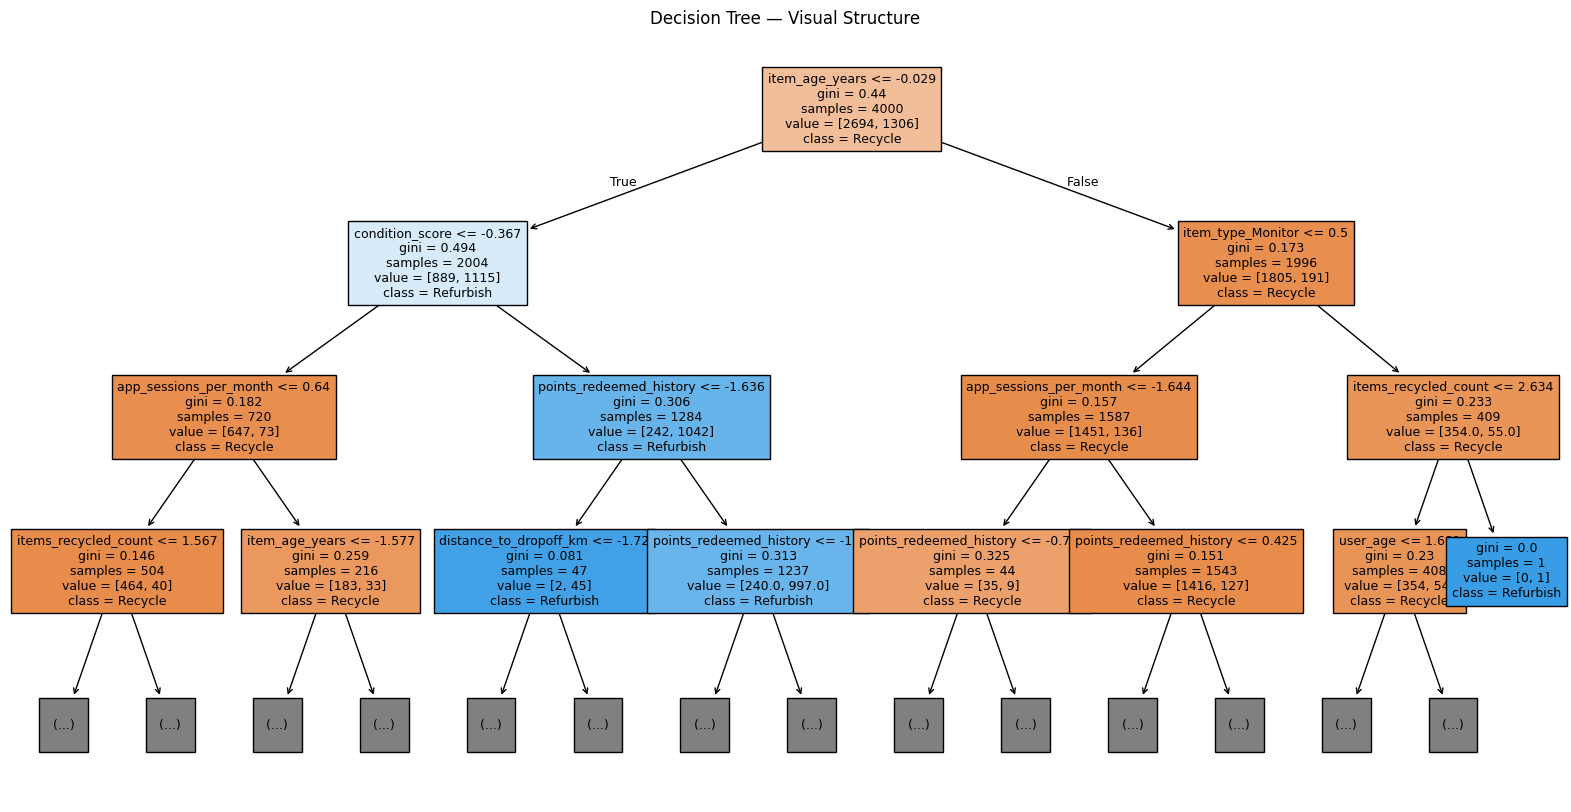

In [ ]:
# Tree Visualization
plt.figure(figsize=(20, 10))
plot_tree(model_dt, max_depth=3, feature_names=X.columns.tolist(),
          class_names=model_dt.classes_.tolist(), filled=True, fontsize=9)
plt.title('Decision Tree — Visual Structure')
plt.show()

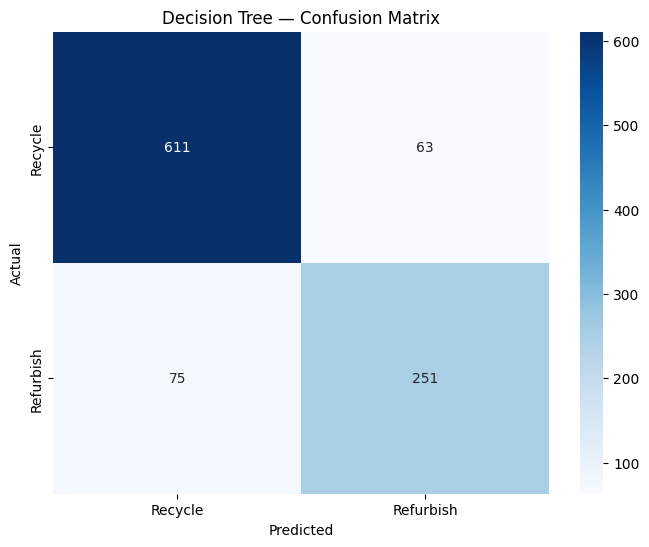

In [ ]:
# Confusion Matrix Heatmap
plt.figure(figsize=(8, 6))
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=model_dt.classes_, yticklabels=model_dt.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree — Confusion Matrix')
plt.show()

In [ ]:
# Classification Report as a styled pandas DataFrame
report_df_dt = pd.DataFrame(classification_report(y_test, y_pred_dt, output_dict=True)).transpose()
report_df_dt = report_df_dt.drop(index=['accuracy', 'macro avg', 'weighted avg'], errors='ignore')

def color_f1_score(val):
    """Colors f1-score values based on a simple gradient."""
    try:
        val = float(val)
        if val > 0.8:
            color = 'background-color: lightgreen'
        elif val > 0.6:
            color = 'background-color: yellow'
        else:
            color = 'background-color: salmon'
        return color
    except ValueError:
        return ''

styled_report_dt = report_df_dt.style.map(color_f1_score, subset=pd.IndexSlice[:, ['f1-score']])
print('Decision Tree — Classification Report')
display(styled_report_dt)

Decision Tree — Classification Report


,precision,recall,f1-score,support
Recycle,0.890671,0.906528,0.898529,674.000000
Refurbish,0.799363,0.769939,0.784375,326.000000


In [ ]:
# Sample Predictions Table
sample_indices = np.random.choice(X_test.index, size=5, replace=False)
sample_X = X_test.loc[sample_indices]
sample_y_actual = y_test.loc[sample_indices]
sample_y_pred = model_dt.predict(sample_X)

sample_predictions_df = pd.DataFrame({
    'Item Index': sample_indices,
    'Predicted Label': sample_y_pred,
    'Actual Label': sample_y_actual,
    'Correct?': (sample_y_pred == sample_y_actual).map({True: 'Yes', False: 'No'})
})

# Display some key features for context
display_features = ['item_age_years', 'condition_score', 'item_type_Smartphone'] # Example features to display
for feature in display_features:
    if feature in sample_X.columns:
        sample_predictions_df[feature] = sample_X[feature].values

# Reorder columns to have features first, then predictions
final_columns = ['Item Index'] + [f for f in display_features if f in X.columns] + ['Predicted Label', 'Actual Label', 'Correct?']
sample_predictions_df = sample_predictions_df[final_columns]

print('Decision Tree — Sample Predictions Walkthrough')
display(sample_predictions_df)

Decision Tree — Sample Predictions Walkthrough


,Item Index,item_age_years,condition_score,item_type_Smartphone,Predicted Label,Actual Label,Correct?
347,347,1.443870,-1.594319,1.0,Recycle,Refurbish,No
4284,4284,0.107932,-0.980458,0.0,Recycle,Recycle,Yes
3011,3011,-1.076196,1.474984,0.0,Refurbish,Refurbish,Yes
4651,4651,-0.226053,0.247263,0.0,Refurbish,Refurbish,Yes
4193,4193,1.777855,0.861124,0.0,Recycle,Recycle,Yes


In [ ]:
# Classification Report as a styled pandas DataFrame
report_df = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).transpose()
# Remove accuracy, macro avg, weighted avg rows for cleaner display of class metrics
report_df = report_df.drop(index=['accuracy', 'macro avg', 'weighted avg'], errors='ignore')

def color_f1_score(val):
    """Colors f1-score values based on a simple gradient."""
    try:
        val = float(val)
        if val > 0.8:
            color = 'background-color: lightgreen'
        elif val > 0.6:
            color = 'background-color: yellow'
        else:
            color = 'background-color: salmon'
        return color
    except ValueError:
        return ''

styled_report = report_df.style.map(color_f1_score, subset=pd.IndexSlice[:, ['f1-score']])
print('Logistic Regression — Classification Report')
display(styled_report)

Logistic Regression — Classification Report


,precision,recall,f1-score,support
Recycle,0.851093,0.924332,0.886202,674.000000
Refurbish,0.809701,0.665644,0.730640,326.000000


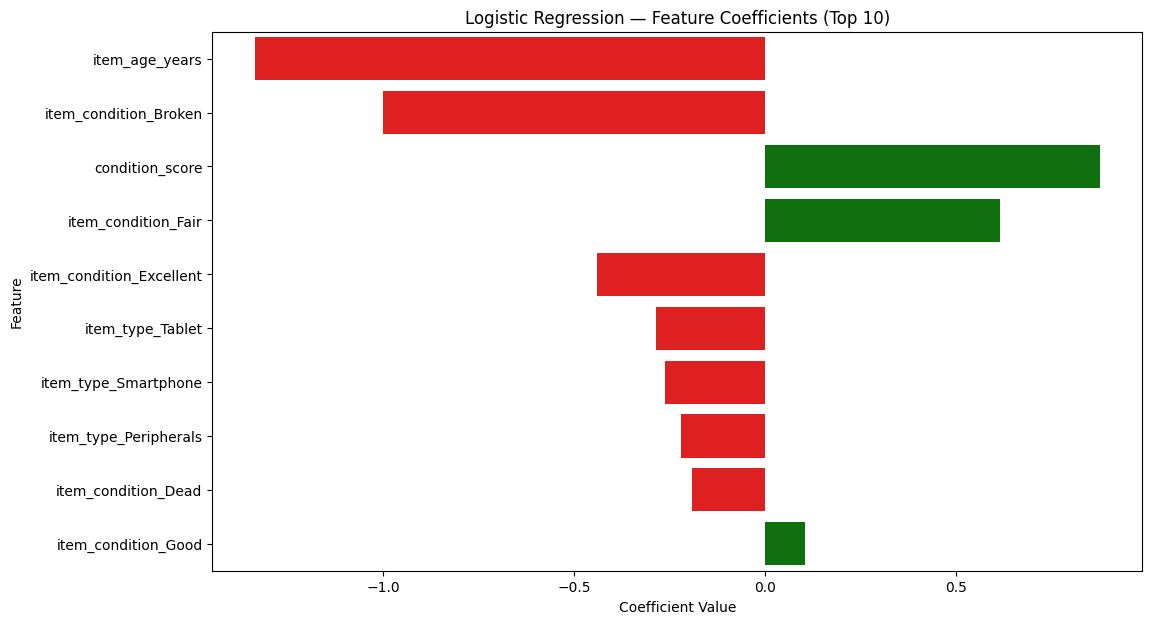

In [ ]:
# Feature Coefficients Bar Chart
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0] # For binary classification, use the first row of coef_
})

# Sort by absolute coefficient value and get top 10
coefficients['Abs_Coefficient'] = coefficients['Coefficient'].abs()
top_10_coefficients = coefficients.sort_values(by='Abs_Coefficient', ascending=False).head(10)

# Create a new column for coloring based on the sign of the coefficient
top_10_coefficients['Coefficient_Sign'] = top_10_coefficients['Coefficient'].apply(lambda x: 'Negative' if x < 0 else 'Positive')

plt.figure(figsize=(12, 7))
sns.barplot(x='Coefficient', y='Feature', data=top_10_coefficients,
            hue='Coefficient_Sign', palette={'Negative': 'red', 'Positive': 'green'}, legend=False)
plt.title('Logistic Regression — Feature Coefficients (Top 10)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.show()

In [ ]:
# Classification Report as a styled pandas DataFrame
report_df = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).transpose()
# Remove accuracy, macro avg, weighted avg rows for cleaner display of class metrics
report_df = report_df.drop(index=['accuracy', 'macro avg', 'weighted avg'], errors='ignore')

def color_f1_score(val):
    """Colors f1-score values based on a simple gradient."""
    try:
        val = float(val)
        if val > 0.8:
            color = 'background-color: lightgreen'
        elif val > 0.6:
            color = 'background-color: yellow'
        else:
            color = 'background-color: salmon'
        return color
    except ValueError:
        return ''

styled_report = report_df.style.map(color_f1_score, subset=pd.IndexSlice[:, ['f1-score']])
print('Logistic Regression — Classification Report')
display(styled_report)

Logistic Regression — Classification Report


,precision,recall,f1-score,support
Recycle,0.851093,0.924332,0.886202,674.000000
Refurbish,0.809701,0.665644,0.730640,326.000000


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define features (X) and target (y)
X = df_processed.drop(columns=['triage_action'])
y = df_processed['triage_action']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize and train the Logistic Regression model
# Logistic Regression is chosen as a baseline due to its simplicity, interpretability, and efficiency.
# Its limitations include assuming a linear relationship between features and the log-odds of the target,
# and it might not capture complex non-linear relationships in the data.
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f'Logistic Regression Baseline Accuracy: {accuracy:.4f}')

print('\nClassification Report:')
print(classification_report(y_test, y_pred))

Logistic Regression Baseline Accuracy: 0.8400

Classification Report:
              precision    recall  f1-score   support

     Recycle       0.85      0.92      0.89       674
   Refurbish       0.81      0.67      0.73       326

    accuracy                           0.84      1000
   macro avg       0.83      0.79      0.81      1000
weighted avg       0.84      0.84      0.84      1000



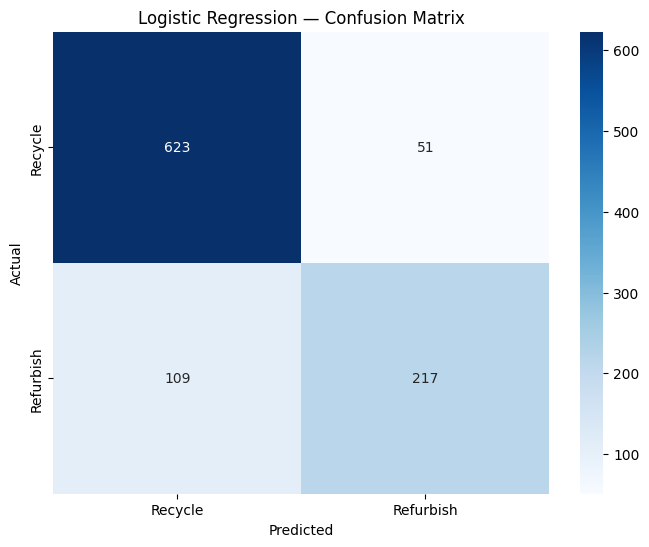

In [ ]:
# Confusion Matrix Heatmap
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression — Confusion Matrix')
plt.show()

In [ ]:
# Classification Report as a styled pandas DataFrame
report_df = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).transpose()
# Remove accuracy, macro avg, weighted avg rows for cleaner display of class metrics
report_df = report_df.drop(index=['accuracy', 'macro avg', 'weighted avg'], errors='ignore')

def color_f1_score(val):
    """Colors f1-score values based on a simple gradient."""
    try:
        val = float(val)
        if val > 0.8:
            color = 'background-color: lightgreen'
        elif val > 0.6:
            color = 'background-color: yellow'
        else:
            color = 'background-color: salmon'
        return color
    except ValueError:
        return ''

styled_report = report_df.style.map(color_f1_score, subset=pd.IndexSlice[:, ['f1-score']])
print('Logistic Regression — Classification Report')
display(styled_report)

Logistic Regression — Classification Report


,precision,recall,f1-score,support
Recycle,0.851093,0.924332,0.886202,674.000000
Refurbish,0.809701,0.665644,0.730640,326.000000


In [ ]:
print(df['item_condition'].value_counts(dropna=False))

item_condition
Fair         1477
Good         1294
Broken        974
Dead          774
Excellent     481
Name: count, dtype: int64


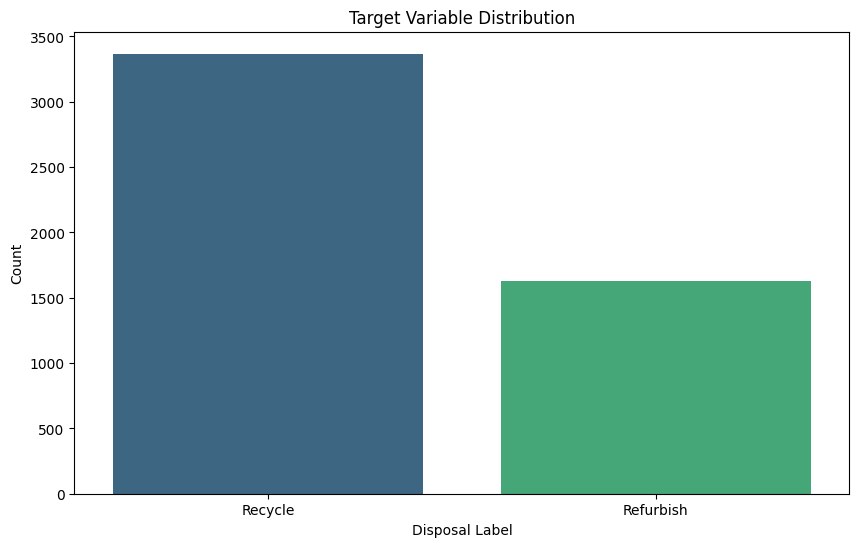

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Class Distribution Bar Chart
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='triage_action', palette='viridis', hue='triage_action', legend=False)
plt.title('Target Variable Distribution')
plt.xlabel('Disposal Label')
plt.ylabel('Count')
plt.show()

Next, to create the 'Condition Score vs Item Age Scatter Plot', I'll first need to convert the `item_condition` (categorical) into a numerical 'condition_score'. Then I'll generate the plot.

Here's the summary table of your dataset *before* any major preprocessing steps like encoding or scaling. This shows missing values, data types, and sample min/max for each column.

In [ ]:
# Before Preprocessing Table
def get_min_max(series):
    if pd.api.types.is_numeric_dtype(series):
        return f'{series.min():.2f} / {series.max():.2f}'
    elif pd.api.types.is_datetime64_any_dtype(series):
        return f'{series.min()} / {series.max()}'
    else:
        return 'N/A'

summary_data = []
for col in df.columns:
    summary_data.append({
        'Column': col,
        'Missing Count': df[col].isnull().sum(),
        'Data Type': df[col].dtype,
        'Sample Min/Max': get_min_max(df[col])
    })

summary_df_before = pd.DataFrame(summary_data)
print('Dataset Summary BEFORE Preprocessing')
display(summary_df_before)

Dataset Summary BEFORE Preprocessing


,Column,Missing Count,Data Type,Sample Min/Max
0,item_type,0,object,N/A
1,item_age_years,0,float64,0.50 / 12.00
2,item_condition,0,object,N/A
3,triage_action,0,object,N/A
4,user_age,0,int64,18.00 / 64.00
5,app_sessions_per_month,0,int64,1.00 / 29.00
6,distance_to_dropoff_km,0,float64,0.50 / 15.00
7,points_redeemed_history,0,int64,0.00 / 9997.00
8,items_recycled_count,0,int64,0.00 / 13.00
9,condition_score,1748,float64,2.00 / 4.00


In [ ]:
import pandas as pd

df = pd.read_csv('/content/ecoloop_mock_dataset.csv')
display(df.head())

,item_type,item_age_years,item_condition,triage_action,user_age,app_sessions_per_month,distance_to_dropoff_km,points_redeemed_history,items_recycled_count
0,Monitor,1.5,Good,Recycle,25,14,6.0,9416,2
1,Peripherals,2.9,Good,Refurbish,64,28,10.9,6276,7
2,Tablet,9.2,Good,Recycle,64,11,9.9,1988,0
3,Peripherals,1.1,Fair,Refurbish,54,24,2.9,6777,5
4,Peripherals,6.2,Good,Recycle,51,29,5.1,6312,9


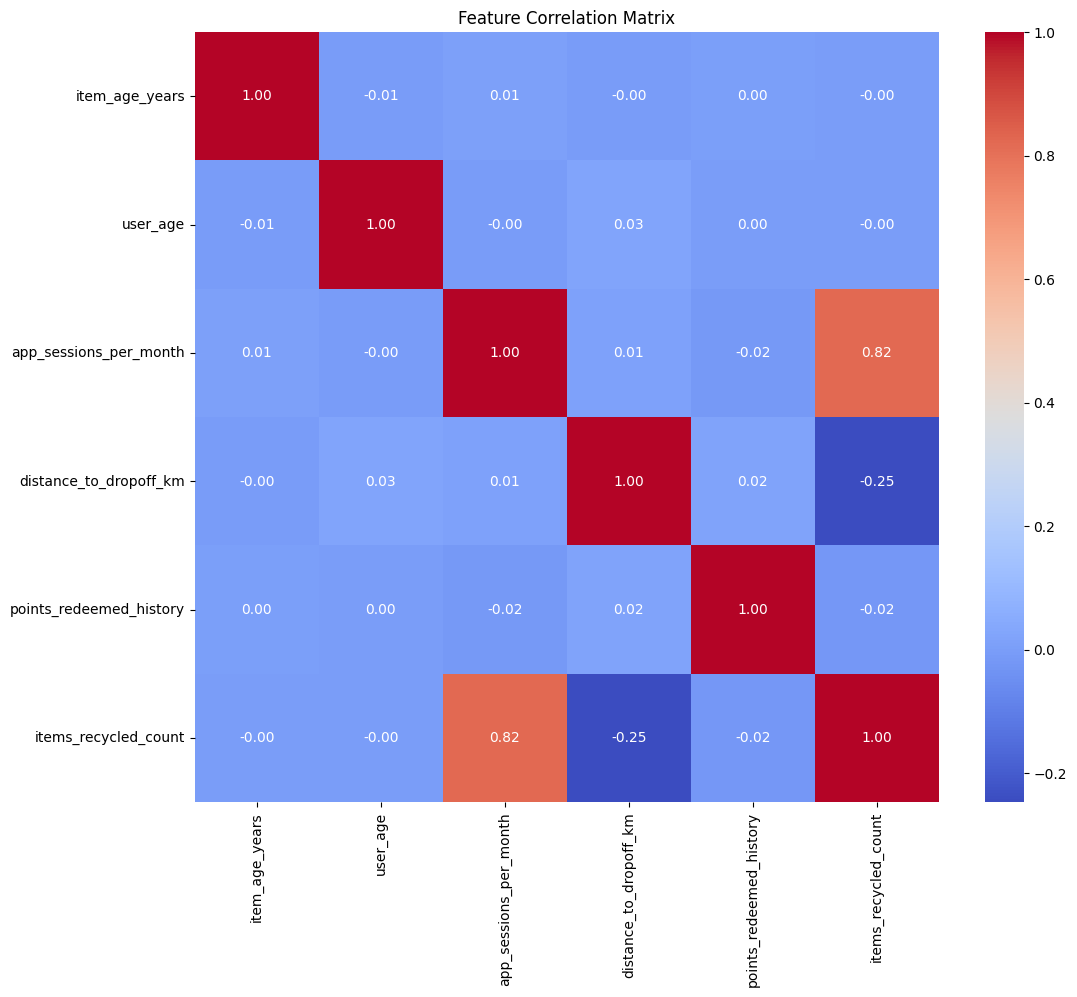

In [ ]:
# Feature Correlation Heatmap

# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(12, 10))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

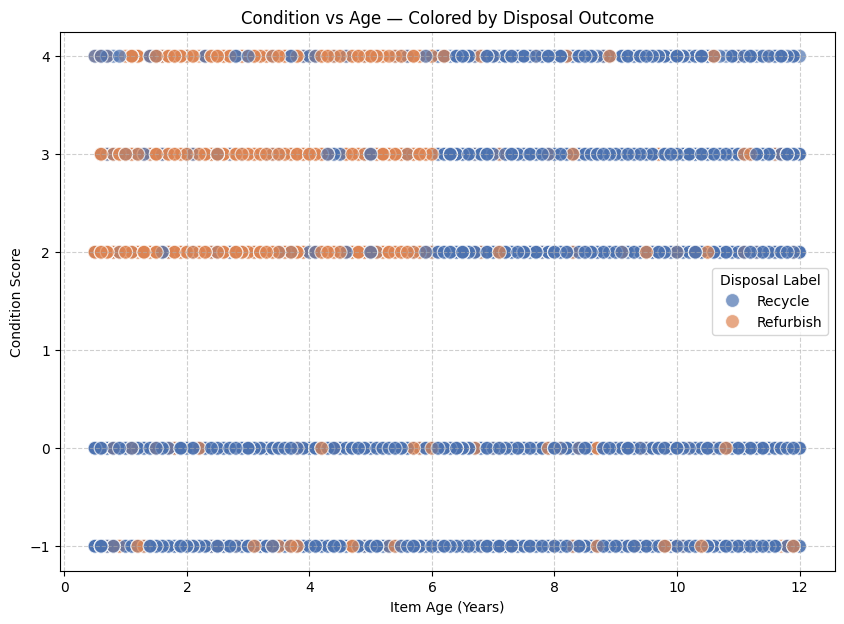

In [ ]:
# Convert item_condition to a numerical score
condition_mapping = {'Dead': -1, 'Broken': 0, 'Poor': 1, 'Fair': 2, 'Good': 3, 'Excellent': 4}
df['condition_score'] = df['item_condition'].map(condition_mapping)

# Condition Score vs Item Age Scatter Plot
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='item_age_years', y='condition_score', hue='triage_action', palette='deep', s=100, alpha=0.7)
plt.title('Condition vs Age — Colored by Disposal Outcome')
plt.xlabel('Item Age (Years)')
plt.ylabel('Condition Score')
plt.legend(title='Disposal Label')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()